In [1]:
# ─── SOURCE  (Starfire nGen-310 — CERN RP Safety File EDMS 3409579 §2.1) ─────
E0_MEV           = 2.45    # [MeV]  DD neutron energy (monoenergetic)
E0_SPREAD_KEV    = 50.0    # [keV]  ±1σ energy spread (doc: ±50 keV)

# ─── B-HDPE SHIELD  (doc §2.2) ───────────────────────────────────────────────
PE_THICKNESS_CM  = 14.0   # [cm]   lateral wall thickness (14 cm B-HDPE)
BHDPE_DENSITY    = 1.0    # [g/cm³]  (doc: 1.0 g/cm³)
BORON_MASS_FRAC  = 0.05   # boron mass fraction (doc: 5% by weight, natural boron)
B10_ENRICHMENT   = 0.199  # B-10 atom fraction (doc: natural boron)

# ─── WOOD LAYER (outer casing, downstream of the B-HDPE) ────────────────────
WOOD_THICKNESS_CM = 1.0   # [cm]   wood panel on the outside of the shield
WOOD_DENSITY      = 0.6   # [g/cm³] typical plywood / soft wood (assumed)
WOOD_H_FRAC       = 0.06  # dry-wood (cellulose-like) mass fractions
WOOD_C_FRAC       = 0.50
WOOD_O_FRAC       = 0.44  # oxygen treated as carbon-equivalent scatterer

TOTAL_SHIELD_CM   = PE_THICKNESS_CM + WOOD_THICKNESS_CM   # 15 cm stack

# ─── GEOMETRY ────────────────────────────────────────────────────────────────
# Isotropic emission, but only directions within a cone around the slab
# normal (pointing at the scintillator tile) are tracked — neutrons emitted
# elsewhere cannot contribute to capture in the tile.
CONE_HALF_ANGLE_DEG = 20.0
AIR_GAP_CM          = 10.0  # wood outer surface → scintillator tile

# Reference values from doc §2.2 — for cross-checks against MC output:
MFP_DOC_CM       = 3.42   # [cm]   mean free path at 2.45 MeV
MACRO_XS_DOC     = 0.292  # [cm⁻¹] macroscopic total cross-section at 2.45 MeV

# lib_neutrons.get_mean_free_path() is hardcoded to rho = 0.95 g/cm³.
# Scale its output to match the actual B-HDPE density (number densities ∝ rho).
MFP_DENSITY_CORRECTION = 0.95 / BHDPE_DENSITY   # 0.95 for density 1.0

# B-10 capture cross-section (1/v law, ENDF/B-VIII.0)
SIGMA_B10_THERMAL_BARNS = 3840.0  # barns at E_THERMAL_EV
E_THERMAL_EV            = 0.0253  # eV (room temperature)

# ─── MONTE CARLO ─────────────────────────────────────────────────────────────
N_NEUTRONS       = 100_000 # number of neutrons to simulate
ABSORPTION_PROB  = 0.02   # H-capture probability per scattering collision
ENERGY_LOSS_FRAC = 0.5    # avg fractional energy loss per H-collision

# ─── PLOT ────────────────────────────────────────────────────────────────────
E_MIN_EV         = 0.01   # [eV]  lower axis limit
E_MAX_EV         = 4e6    # [eV]  upper axis limit


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import numpy as np
import matplotlib.pyplot as plt
from lib_neutrons import calculate_moderated_spectrum, calculate_flux_fractions, get_mean_free_path

N_A   = 6.022e23
M_B10 = 10.0  # g/mol

# B-10 number density in B-HDPE
n_B10 = (BHDPE_DENSITY * BORON_MASS_FRAC * B10_ENRICHMENT / M_B10) * N_A  # cm⁻³

# Cross-check: MFP at 2.45 MeV after density correction vs. doc reference
mfp_lib  = get_mean_free_path(E0_MEV * 1e6) * MFP_DENSITY_CORRECTION
print(f"B-10 number density          : {n_B10:.3e} cm⁻³")
print(f"MFP at 2.45 MeV (lib×corr)  : {mfp_lib:.2f} cm  (doc: {MFP_DOC_CM} cm)")
print(f"Σ   at 2.45 MeV (lib×corr)  : {1/mfp_lib:.3f} cm⁻¹  (doc: {MACRO_XS_DOC} cm⁻¹)")

# ── Analytical moderation (plain PE model — boron does not scatter) ──────────
E0_kev               = E0_MEV * 1e3
initial_energies_kev = np.logspace(-3, 4, 2000)
sigma_kev            = E0_SPREAD_KEV                    # ±50 keV from doc
initial_spectrum     = np.exp(-0.5 * ((initial_energies_kev - E0_kev) / sigma_kev) ** 2)

mod_E_kev, mod_spectrum = calculate_moderated_spectrum(
    initial_energies_kev, initial_spectrum,
    hdpe_thickness_cm=PE_THICKNESS_CM)

# ── Apply B-10 capture suppression (approximate post-correction) ─────────────
mod_E_eV     = mod_E_kev * 1e3
sigma_B10    = SIGMA_B10_THERMAL_BARNS * np.sqrt(E_THERMAL_EV / np.maximum(mod_E_eV, E_THERMAL_EV))
Sigma_B10    = n_B10 * sigma_B10 * 1e-24
B10_survival = np.exp(-Sigma_B10 * PE_THICKNESS_CM)
mod_spectrum_bhdpe = mod_spectrum * B10_survival

fracs_pe    = calculate_flux_fractions(mod_E_kev, mod_spectrum)
fracs_bhdpe = calculate_flux_fractions(mod_E_kev, mod_spectrum_bhdpe)

print(f"\nAnalytical — plain PE vs B-HDPE ({BORON_MASS_FRAC*100:.0f}% B, natural)")
print(f"{'Region':<22} {'Plain PE':>10} {'B-HDPE':>10}")
print("-" * 44)
for key in ('cold', 'thermal', 'epithermal', 'fast'):
    print(f"  {key:<20} {fracs_pe[key]*100:>9.1f}% {fracs_bhdpe[key]*100:>9.1f}%")


✓ Particle Detectors Physics Library loaded successfully!
  - MaterialDatabase: 92 elements + 6 compounds
  - NuclearDatabase: 13 isotopes
  - Bethe-Bloch, neutron capture, and photon attenuation functions available
✓ lib_neutrons loaded: plotting, AmBe spectrum, moderation, ToF, ENDF data
B-10 number density          : 5.992e+20 cm⁻³
MFP at 2.45 MeV (lib×corr)  : 3.83 cm  (doc: 3.42 cm)
Σ   at 2.45 MeV (lib×corr)  : 0.261 cm⁻¹  (doc: 0.292 cm⁻¹)

Analytical — plain PE vs B-HDPE (5% B, natural)
Region                   Plain PE     B-HDPE
--------------------------------------------
  cold                       1.1%       0.0%
  thermal                   98.9%     100.0%
  epithermal                 0.0%       0.0%
  fast                       0.0%       0.0%


In [3]:
import time as time_module
from lib_neutrons import calculate_energy_fractions, get_endf_cross_sections

E0_eV  = E0_MEV * 1e6
N_A_mc = 6.022e23

# ── B-HDPE number densities (doc §2.2) ───────────────────────────────────────
BHDPE_H_FRAC = 0.143
BHDPE_C_FRAC = 0.807
n_H_bhdpe = (BHDPE_DENSITY * BHDPE_H_FRAC / 1.0)  * N_A_mc   # cm⁻³
n_C_bhdpe = (BHDPE_DENSITY * BHDPE_C_FRAC / 12.0) * N_A_mc   # cm⁻³

# ── Wood number densities (O folded into C: similar σ, A close enough) ───────
n_H_wood   = (WOOD_DENSITY * WOOD_H_FRAC / 1.0)  * N_A_mc
n_C_wood   = (WOOD_DENSITY * WOOD_C_FRAC / 12.0) * N_A_mc
n_O_wood   = (WOOD_DENSITY * WOOD_O_FRAC / 16.0) * N_A_mc
n_Ceq_wood = n_C_wood + n_O_wood
print(f"B-HDPE: n_H = {n_H_bhdpe:.3e}   n_C    = {n_C_bhdpe:.3e} cm⁻³")
print(f"Wood  : n_H = {n_H_wood:.3e}   n_C+O = {n_Ceq_wood:.3e} cm⁻³")

# ── Per-layer Σ_scatter and H-scatter-fraction tables in log-E space ─────────
# layer 0 = B-HDPE [0, 14 cm),  layer 1 = wood [14, 15 cm)
_E_tbl           = np.logspace(np.log10(0.025), np.log10(E0_eV * 1.5), 2000)
_sH_tbl, _sC_tbl = get_endf_cross_sections(_E_tbl)
_logE_tbl        = np.log(_E_tbl)

_Ss_tbl = [(n_H_bhdpe * _sH_tbl + n_C_bhdpe  * _sC_tbl) * 1e-24,
           (n_H_wood  * _sH_tbl + n_Ceq_wood * _sC_tbl) * 1e-24]
_fH_tbl = [(n_H_bhdpe * _sH_tbl * 1e-24) / _Ss_tbl[0],
           (n_H_wood  * _sH_tbl * 1e-24) / _Ss_tbl[1]]
n_B10_layer = [n_B10, 0.0]   # no boron in the wood

def Sigma_scatter_of(E, layer):
    return float(np.interp(np.log(max(E, 0.025)), _logE_tbl, _Ss_tbl[layer]))

def h_frac(E, layer):
    return float(np.interp(np.log(max(E, 0.025)), _logE_tbl, _fH_tbl[layer]))

print(f"MFP at 2.45 MeV in B-HDPE      : {1/Sigma_scatter_of(E0_eV, 0):.2f} cm  (doc: {MFP_DOC_CM} cm)")
print(f"MFP at 2.45 MeV in wood        : {1/Sigma_scatter_of(E0_eV, 1):.2f} cm")
print(f"H-scatter fraction at 2.45 MeV : {h_frac(E0_eV, 0)*100:.1f}% (B-HDPE)  {h_frac(E0_eV, 1)*100:.1f}% (wood)")

# ── Direction-update: apply scatter angle θ to current direction cosine μ ─────
# cos_theta is the polar scatter angle relative to the neutron's current direction.
# Only the z-component (slab normal) is tracked; azimuthal angle φ is random.
def update_mu(mu, cos_theta):
    sin_theta = np.sqrt(max(1.0 - cos_theta**2, 0.0))
    sin_mu    = np.sqrt(max(1.0 - mu**2,        0.0))
    if sin_mu < 1e-10:                         # moving exactly along ±z
        return cos_theta if mu > 0 else -cos_theta
    cos_phi = 2.0 * np.random.random() - 1.0  # azimuthal angle uniform [0, 2π]
    return mu * cos_theta + sin_mu * sin_theta * cos_phi

# ── MC arrays ─────────────────────────────────────────────────────────────────
E_final_eV    = np.zeros(N_NEUTRONS)
n_collisions  = np.zeros(N_NEUTRONS, dtype=int)
absorbed      = np.zeros(N_NEUTRONS, dtype=bool)
abs_by_boron  = np.zeros(N_NEUTRONS, dtype=bool)
transmitted   = np.zeros(N_NEUTRONS, dtype=bool)

MU_MIN = np.cos(np.radians(CONE_HALF_ANGLE_DEG))   # cone acceptance on emission
Z1     = PE_THICKNESS_CM                            # B-HDPE / wood boundary
Z2     = TOTAL_SHIELD_CM                            # wood / air boundary
EPS    = 1e-9

print(f"\nMC: {N_NEUTRONS:,} neutrons at {E0_MEV} MeV through "
      f"{PE_THICKNESS_CM:.0f} cm B-HDPE + {WOOD_THICKNESS_CM:.0f} cm wood")
print(f"    isotropic emission within {CONE_HALF_ANGLE_DEG:.0f}° cone "
      f"(μ₀ ∈ [{MU_MIN:.4f}, 1])")
print(f"    1-D layered slab: exact H (A=1) and C (A=12) elastic kinematics")
t0  = time_module.time()
A_C = 12.0

for i in range(N_NEUTRONS):
    E      = E0_eV
    pos    = 0.0
    # isotropic within the cone: cosθ₀ uniform in [cos(20°), 1]
    mu     = MU_MIN + (1.0 - MU_MIN) * np.random.random()
    n_coll = 0
    dead   = False
    boron  = False
    trans  = False

    while True:
        layer = 0 if pos < Z1 else 1

        # ── free path to next interaction (layer-dependent Σ) ────────────────
        Sigma_scatter = Sigma_scatter_of(E, layer)
        sigma_b10    = SIGMA_B10_THERMAL_BARNS * np.sqrt(E_THERMAL_EV / max(E, E_THERMAL_EV))
        Sigma_b10    = n_B10_layer[layer] * sigma_b10 * 1e-24
        Sigma_total  = Sigma_scatter + Sigma_b10
        step         = -np.log(np.random.random()) / Sigma_total

        # ── distance to nearest layer boundary along current direction ───────
        if mu > 0:
            dist_face = ((Z1 if layer == 0 else Z2) - pos) / mu
        elif mu < 0:
            dist_face = (pos - (0.0 if layer == 0 else Z1)) / (-mu)
        else:
            dist_face = 1e30

        if step >= dist_face:
            pos += dist_face * mu + EPS * np.sign(mu)   # cross the boundary
            if pos >= Z2:                                # exits downstream
                trans = True
                break
            if pos <= 0.0:                               # exits at source face
                trans = False
                break
            continue                                     # internal boundary: resample

        pos    += step * mu
        n_coll += 1

        # ── B-10 capture? (only in the B-HDPE layer) ──────────────────────────
        if np.random.random() * Sigma_total < Sigma_b10:
            dead = True; boron = True; break

        # ── elastic scatter: H or C? ──────────────────────────────────────────
        if np.random.random() < h_frac(E, layer):
            # ── H (A=1): exact lab-frame kinematics ──────────────────────────
            # CM scatter isotropic → cos_theta_lab = sqrt(U) ∈ [0, 1]
            # Neutron stays in forward hemisphere; E' = E·cos²θ_lab
            c = np.sqrt(np.random.random())   # cos_theta_lab
            E  = max(E * c * c, 0.025)
            mu = update_mu(mu, c)
            # H radiative capture (small probability)
            if np.random.random() < ABSORPTION_PROB:
                dead = True; break
        else:
            # ── C (A=12): exact kinematics from isotropic CM scatter ──────────
            # cos_theta_CM uniform [-1, 1]; neutron can scatter into backward
            # lab hemisphere when cos_CM < -1/A_C
            cos_CM = 2.0 * np.random.random() - 1.0
            denom  = 1.0 + 2.0 * A_C * cos_CM + A_C**2
            E      = max(E * denom / (A_C + 1.0)**2, 0.025)
            c      = (1.0 + A_C * cos_CM) / np.sqrt(denom)   # cos_theta_lab
            mu     = update_mu(mu, c)

    E_final_eV[i]   = E
    n_collisions[i] = n_coll
    absorbed[i]     = dead
    abs_by_boron[i] = boron
    transmitted[i]  = trans

    if (i + 1) % 25_000 == 0:
        print(f"  {i+1:,}/{N_NEUTRONS:,} ({100*(i+1)/N_NEUTRONS:.0f}%)")

elapsed   = time_module.time() - t0
survived  = transmitted
n_surv    = np.sum(survived)
n_back    = np.sum(~absorbed & ~transmitted)
n_abs_B10 = np.sum(abs_by_boron)
n_abs_H   = np.sum(absorbed & ~abs_by_boron)

fracs_mc = calculate_energy_fractions(E_final_eV[survived])
print(f"\n✓ Done in {elapsed:.1f} s  ({int(N_NEUTRONS/elapsed):,} n/s)")
print(f"  Transmitted (forward) : {n_surv:,} ({100*n_surv/N_NEUTRONS:.2f}%)")
print(f"  Backscattered         : {n_back:,} ({100*n_back/N_NEUTRONS:.2f}%)")
print(f"  B-10 capture          : {n_abs_B10:,} ({100*n_abs_B10/N_NEUTRONS:.1f}%)")
print(f"  H capture             : {n_abs_H:,} ({100*n_abs_H/N_NEUTRONS:.1f}%)")
print(f"  Mean coll (transmitted): {np.mean(n_collisions[survived]):.1f}")
print(f"  Thermal     : {fracs_mc['thermal']*100:.1f}%")
print(f"  Epithermal  : {fracs_mc['epithermal']*100:.1f}%")
print(f"  Fast        : {fracs_mc['fast']*100:.1f}%")
print(f"  Mean E      : {fracs_mc['mean_eV']:.2f} eV   Median E: {fracs_mc['median_eV']:.2f} eV")


B-HDPE: n_H = 8.611e+22   n_C    = 4.050e+22 cm⁻³
Wood  : n_H = 2.168e+22   n_C+O = 2.499e+22 cm⁻³
MFP at 2.45 MeV in B-HDPE      : 3.90 cm  (doc: 3.42 cm)
MFP at 2.45 MeV in wood        : 10.51 cm
H-scatter fraction at 2.45 MeV : 67.3% (B-HDPE)  45.6% (wood)

MC: 100,000 neutrons at 2.45 MeV through 14 cm B-HDPE + 1 cm wood
    isotropic emission within 20° cone (μ₀ ∈ [0.9397, 1])
    1-D layered slab: exact H (A=1) and C (A=12) elastic kinematics


  25,000/100,000 (25%)


  50,000/100,000 (50%)


  75,000/100,000 (75%)


  100,000/100,000 (100%)

✓ Done in 4.1 s  (24,102 n/s)
  Transmitted (forward) : 15,100 (15.10%)
  Backscattered         : 21,326 (21.33%)
  B-10 capture          : 46,422 (46.4%)
  H capture             : 17,152 (17.2%)
  Mean coll (transmitted): 4.6
  Thermal     : 8.0%
  Epithermal  : 31.8%
  Fast        : 59.9%
  Mean E      : 1082286.81 eV   Median E: 898850.18 eV


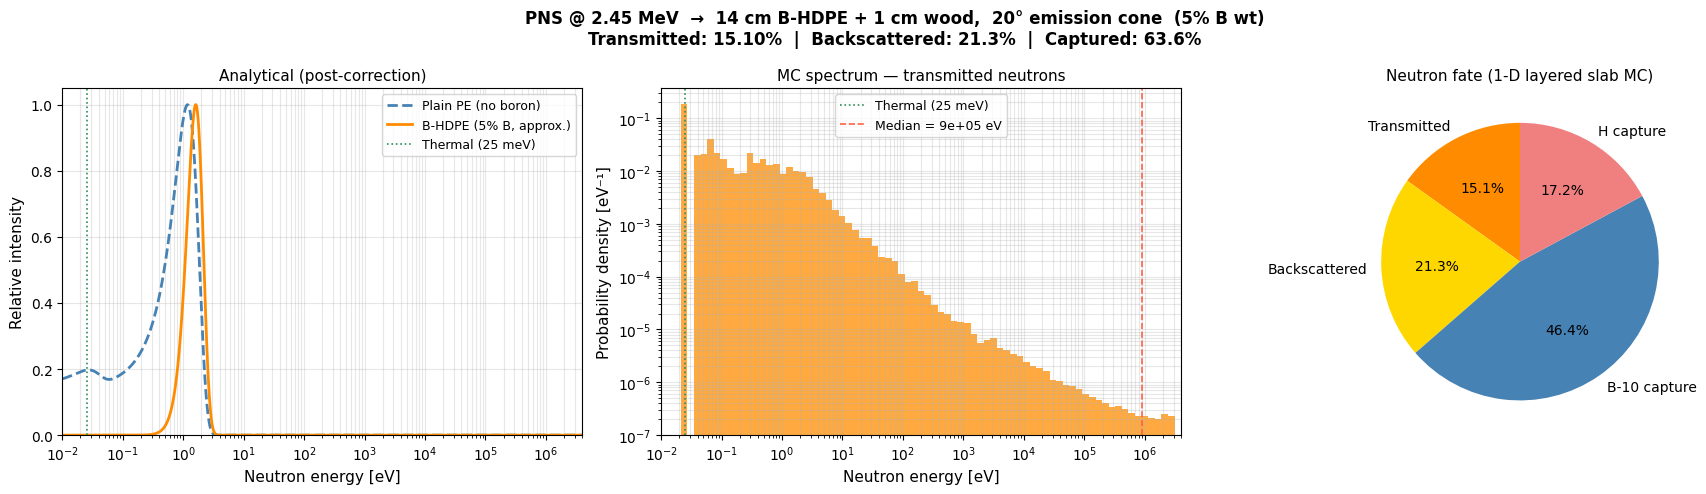

Saved → pns_bhdpe_spectrum.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Left: analytical — plain PE vs B-HDPE ────────────────────────────────────
ax = axes[0]
norm_pe    = np.max(mod_spectrum)      if np.max(mod_spectrum)      > 0 else 1
norm_bhdpe = np.max(mod_spectrum_bhdpe) if np.max(mod_spectrum_bhdpe) > 0 else 1
ax.semilogx(mod_E_eV, mod_spectrum       / norm_pe,    color='steelblue', lw=2,
            ls='--', label='Plain PE (no boron)')
ax.semilogx(mod_E_eV, mod_spectrum_bhdpe / norm_bhdpe, color='darkorange', lw=2,
            label=f'B-HDPE ({BORON_MASS_FRAC*100:.0f}% B, approx.)')
ax.axvline(0.0253, color='seagreen', ls=':', lw=1.2, label='Thermal (25 meV)')
ax.set_xlabel('Neutron energy [eV]', fontsize=11)
ax.set_ylabel('Relative intensity', fontsize=11)
ax.set_title('Analytical (post-correction)', fontsize=11)
ax.set_xlim(E_MIN_EV, E_MAX_EV)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# ── Centre: MC energy spectrum ────────────────────────────────────────────────
ax2 = axes[1]
bins = np.logspace(np.log10(E_MIN_EV), np.log10(E_MAX_EV), 80)
ax2.hist(E_final_eV[survived], bins=bins, color='darkorange', alpha=0.75,
         edgecolor='none', density=True)
ax2.axvline(0.0253, color='seagreen', ls=':', lw=1.2, label='Thermal (25 meV)')
ax2.axvline(fracs_mc['median_eV'], color='tomato', ls='--', lw=1.2,
            label=f"Median = {fracs_mc['median_eV']:.2g} eV")
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Neutron energy [eV]', fontsize=11)
ax2.set_ylabel('Probability density [eV⁻¹]', fontsize=11)
ax2.set_title(f'MC spectrum — transmitted neutrons', fontsize=11)
ax2.set_xlim(E_MIN_EV, E_MAX_EV)
ax2.legend(fontsize=9)
ax2.grid(True, which='both', alpha=0.3)

# ── Right: fate breakdown (pie) — now 4 slices ───────────────────────────────
ax3 = axes[2]
frac_surv  = n_surv  / N_NEUTRONS
frac_back  = n_back  / N_NEUTRONS
frac_b10   = n_abs_B10 / N_NEUTRONS
frac_h     = n_abs_H   / N_NEUTRONS
wedges, texts, autotexts = ax3.pie(
    [frac_surv, frac_back, frac_b10, frac_h],
    labels=['Transmitted', 'Backscattered', 'B-10 capture', 'H capture'],
    colors=['darkorange', 'gold', 'steelblue', 'lightcoral'],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 10})
ax3.set_title('Neutron fate (1-D layered slab MC)', fontsize=11)

fig.suptitle(
    f'PNS @ {E0_MEV} MeV  →  {PE_THICKNESS_CM:.0f} cm B-HDPE + {WOOD_THICKNESS_CM:.0f} cm wood,  '
    f'{CONE_HALF_ANGLE_DEG:.0f}° emission cone  ({BORON_MASS_FRAC*100:.0f}% B wt)\n'
    f'Transmitted: {100*frac_surv:.2f}%  |  '
    f'Backscattered: {100*frac_back:.1f}%  |  '
    f'Captured: {100*(frac_b10+frac_h):.1f}%',
    fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('pns_bhdpe_spectrum.png', dpi=120)
plt.show()
print("Saved → pns_bhdpe_spectrum.png")

In [5]:
# ─── Parameters ──────────────────────────────────────────────────────────────
EMISSION_RATE      = 1e7   # [n/s]  source rate (doc max: 1e7 n/s)
# Source sits at the inner shield face: 14 cm B-HDPE + 1 cm wood + 10 cm air gap
DISTANCE_CM        = TOTAL_SHIELD_CM + AIR_GAP_CM   # [cm] = 25 cm source → tile
SURFACE_AREA_CM2   = 9.0   # [cm²]  detector surface (e.g. 3×3 cm tile)

# ─── Flux calculation (isotropic point source) ────────────────────────────────
# The MC gives the survival fraction for neutrons emitted within the 20° cone
# toward the tile (the only ones that can contribute).
# Beyond the shield the field is treated as isotropic → 1/r² dilution only.
transmission = n_surv / N_NEUTRONS                         # shield survival fraction

flux_cm2_s = EMISSION_RATE * transmission / (4 * np.pi * DISTANCE_CM**2)  # [n/cm²/s]
rate_surface = flux_cm2_s * SURFACE_AREA_CM2               # [n/s] through the surface

print(f"Source emission rate      : {EMISSION_RATE:.1e} n/s")
cone_frac = 0.5 * (1.0 - np.cos(np.radians(CONE_HALF_ANGLE_DEG)))
tile_half_angle = np.degrees(np.arctan(np.sqrt(SURFACE_AREA_CM2)/2 / DISTANCE_CM))
print(f"Cone solid-angle fraction : {cone_frac*100:.2f}% of 4π  "
      f"(tile subtends ±{tile_half_angle:.1f}°, inside the {CONE_HALF_ANGLE_DEG:.0f}° cone)")
print(f"Shield transmission (MC)  : {transmission*100:.2f}%  "
      f"({n_surv:,} / {N_NEUTRONS:,} neutrons)")
print(f"Distance from source      : {DISTANCE_CM:.1f} cm  ({DISTANCE_CM/100:.2f} m)")
print(f"Surface area              : {SURFACE_AREA_CM2:.1f} cm²")
print()
print(f"Flux at surface           : {flux_cm2_s:.3e} n/cm²/s")
print(f"Rate through surface      : {rate_surface:.3e} n/s")
print(f"                          = {rate_surface*3600:.3e} n/hr")


Source emission rate      : 1.0e+07 n/s
Cone solid-angle fraction : 3.02% of 4π  (tile subtends ±3.4°, inside the 20° cone)
Shield transmission (MC)  : 15.10%  (15,100 / 100,000 neutrons)
Distance from source      : 25.0 cm  (0.25 m)
Surface area              : 9.0 cm²

Flux at surface           : 1.923e+02 n/cm²/s
Rate through surface      : 1.730e+03 n/s
                          = 6.229e+06 n/hr


In [6]:
# ─── Scintillator parameters ─────────────────────────────────────────────────
SCINT_THICKNESS_CM   = 1.0    # [cm]   sample thickness
SCINT_DENSITY        = 1.05   # [g/cm³] typical plastic scintillator (PVT/PS)
SCINT_BORON_FRAC     = 0.02   # boron mass fraction (2% doping)
SCINT_B10_ENRICHMENT = 0.199  # B-10 atom fraction (natural boron)

# ─── B-10 number density in scintillator ─────────────────────────────────────
N_A_loc   = 6.022e23
M_B10_loc = 10.0
n_B10_scint = (SCINT_DENSITY * SCINT_BORON_FRAC * SCINT_B10_ENRICHMENT / M_B10_loc) * N_A_loc

# ─── Energy-resolved interaction probability (using MC spectrum) ──────────────
# For each surviving neutron from the shield MC, compute the probability that
# it undergoes a B-10 capture in 1 cm of scintillator.
# σ_B10(E) follows 1/v → σ = σ_thermal × √(E_thermal / E)
E_surv = E_final_eV[survived]   # energy array for transmitted neutrons

sigma_b10_scint = SIGMA_B10_THERMAL_BARNS * np.sqrt(E_THERMAL_EV / np.maximum(E_surv, E_THERMAL_EV))
Sigma_b10_scint = n_B10_scint * sigma_b10_scint * 1e-24    # macroscopic [cm⁻¹]
p_interact      = 1.0 - np.exp(-Sigma_b10_scint * SCINT_THICKNESS_CM)

mean_p   = np.mean(p_interact)
median_p = np.median(p_interact)

# ─── Event rate ───────────────────────────────────────────────────────────────
# rate_surface neutrons/s enter the surface; mean_p of them interact via B-10
event_rate = rate_surface * mean_p

print(f"Scintillator: {SCINT_THICKNESS_CM} cm thick, "
      f"ρ = {SCINT_DENSITY} g/cm³, "
      f"B = {SCINT_BORON_FRAC*100:.0f}% wt (natural)")
print(f"n_B10 in scintillator     : {n_B10_scint:.3e} cm⁻³")
print()
print(f"B-10 interaction prob (mean)  : {mean_p*100:.3f}%  (averaged over MC spectrum)")
print(f"B-10 interaction prob (median): {median_p*100:.3f}%")
print()
print(f"Neutron rate through surface  : {rate_surface:.3e} n/s")
print(f"B-10 event rate in scintillator: {event_rate:.3e} events/s")
print(f"                               = {event_rate*3600:.3e} events/hr")
print(f"                               = {event_rate*3600*24:.3e} events/day")

# ─── Per-energy-group breakdown ───────────────────────────────────────────────
print()
print("Interaction prob by energy group (from MC spectrum):")
groups = [
    ("thermal   (<1 eV)",       E_surv <  1.0),
    ("epithermal (1 eV–100 keV)", (E_surv >= 1.0) & (E_surv < 1e5)),
    ("fast      (>100 keV)",    E_surv >= 1e5),
]
for label, mask in groups:
    if np.any(mask):
        p_grp = np.mean(p_interact[mask])
        frac  = np.sum(mask) / len(E_surv)
        print(f"  {label}: p = {p_grp*100:.3f}%  ({frac*100:.1f}% of survivors)")
    else:
        print(f"  {label}: no neutrons in this group")


Scintillator: 1.0 cm thick, ρ = 1.05 g/cm³, B = 2% wt (natural)
n_B10 in scintillator     : 2.517e+20 cm⁻³

B-10 interaction prob (mean)  : 0.871%  (averaged over MC spectrum)
B-10 interaction prob (median): 0.016%

Neutron rate through surface  : 1.730e+03 n/s
B-10 event rate in scintillator: 1.507e+01 events/s
                               = 5.423e+04 events/hr
                               = 1.302e+06 events/day

Interaction prob by energy group (from MC spectrum):
  thermal   (<1 eV): p = 26.043%  (1.6% of survivors)
  epithermal (1 eV–100 keV): p = 1.989%  (22.8% of survivors)
  fast      (>100 keV): p = 0.017%  (75.7% of survivors)


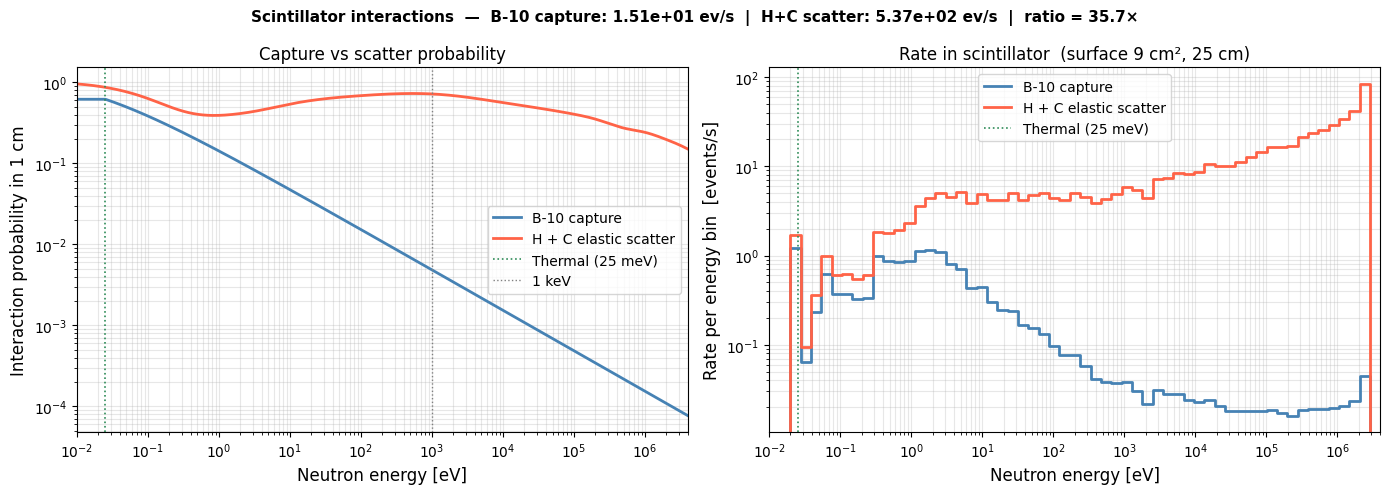

Total B-10 capture rate : 1.507e+01 events/s
Total H+C scatter rate  : 5.372e+02 events/s
Scatter / capture ratio : 35.7


In [7]:
from lib_neutrons import get_endf_cross_sections

# ─── Scintillator composition (PVT ≈ C₉H₁₀, 2% B doping) ────────────────────
# Remaining 98% of mass is the polymer base.  PVT: ~8.47% H, ~91.53% C by mass.
SCINT_H_FRAC = (1.0 - SCINT_BORON_FRAC) * (10 / 118)    # ≈ 0.0830
SCINT_C_FRAC = (1.0 - SCINT_BORON_FRAC) * (108 / 118)   # ≈ 0.8967

n_H_scint = (SCINT_DENSITY * SCINT_H_FRAC / 1.0)  * N_A_loc   # cm⁻³
n_C_scint = (SCINT_DENSITY * SCINT_C_FRAC / 12.0) * N_A_loc   # cm⁻³

# ─── Energy grid for smooth probability curves ────────────────────────────────
E_grid = np.logspace(np.log10(E_MIN_EV), np.log10(E_MAX_EV), 500)

sigma_H_grid, sigma_C_grid = get_endf_cross_sections(E_grid)
Sigma_scatter_grid = (n_H_scint * sigma_H_grid + n_C_scint * sigma_C_grid) * 1e-24  # cm⁻¹

sigma_b10_grid = SIGMA_B10_THERMAL_BARNS * np.sqrt(E_THERMAL_EV / np.maximum(E_grid, E_THERMAL_EV))
Sigma_b10_grid = n_B10_scint * sigma_b10_grid * 1e-24   # cm⁻¹

p_scatter_grid = 1.0 - np.exp(-Sigma_scatter_grid * SCINT_THICKNESS_CM)
p_capture_grid = 1.0 - np.exp(-Sigma_b10_grid     * SCINT_THICKNESS_CM)

# ─── Rate per energy bin (weighted by MC spectrum) ────────────────────────────
bins = np.logspace(np.log10(E_MIN_EV), np.log10(E_MAX_EV), 60)
bin_centres = np.sqrt(bins[:-1] * bins[1:])   # geometric mean

# p_capture and p_scatter per surviving MC neutron
sigma_H_mc, sigma_C_mc = get_endf_cross_sections(E_surv)
Sigma_scatter_mc = (n_H_scint * sigma_H_mc + n_C_scint * sigma_C_mc) * 1e-24
p_scatter_mc = 1.0 - np.exp(-Sigma_scatter_mc * SCINT_THICKNESS_CM)
# p_interact (B-10 capture) already computed in previous cell as p_interact

bin_idx = np.digitize(E_surv, bins) - 1   # which bin each neutron falls into
n_bins  = len(bin_centres)

rate_capture_bin  = np.zeros(n_bins)
rate_scatter_bin  = np.zeros(n_bins)

for k in range(n_bins):
    mask_k = bin_idx == k
    if np.any(mask_k):
        # fraction of surface flux in this bin × respective probability → events/s
        flux_frac = np.sum(mask_k) / len(E_surv)
        rate_capture_bin[k] = rate_surface * flux_frac * np.mean(p_interact[mask_k])
        rate_scatter_bin[k] = rate_surface * flux_frac * np.mean(p_scatter_mc[mask_k])

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: interaction probability vs energy
ax1.loglog(E_grid, p_capture_grid, color='steelblue', lw=2,
           label='B-10 capture')
ax1.loglog(E_grid, p_scatter_grid, color='tomato',    lw=2,
           label='H + C elastic scatter')
ax1.axvline(0.0253, color='seagreen', ls=':', lw=1.2, label='Thermal (25 meV)')
ax1.axvline(1e3,    color='gray',     ls=':', lw=1.0, label='1 keV')
ax1.set_xlabel('Neutron energy [eV]', fontsize=12)
ax1.set_ylabel(f'Interaction probability in {SCINT_THICKNESS_CM:.0f} cm', fontsize=12)
ax1.set_title('Capture vs scatter probability', fontsize=12)
ax1.set_xlim(E_MIN_EV, E_MAX_EV)
ax1.legend(fontsize=10)
ax1.grid(True, which='both', alpha=0.3)

# Right: rate per energy bin
ax2.step(bin_centres, rate_capture_bin, where='mid', color='steelblue', lw=2,
         label='B-10 capture')
ax2.step(bin_centres, rate_scatter_bin, where='mid', color='tomato',    lw=2,
         label='H + C elastic scatter')
ax2.axvline(0.0253, color='seagreen', ls=':', lw=1.2, label='Thermal (25 meV)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Neutron energy [eV]', fontsize=12)
ax2.set_ylabel('Rate per energy bin  [events/s]', fontsize=12)
ax2.set_title(f'Rate in scintillator  (surface {SURFACE_AREA_CM2:.0f} cm², {DISTANCE_CM:.0f} cm)', fontsize=12)
ax2.set_xlim(E_MIN_EV, E_MAX_EV)
ax2.legend(fontsize=10)
ax2.grid(True, which='both', alpha=0.3)

total_capture_rate  = np.sum(rate_capture_bin)
total_scatter_rate  = np.sum(rate_scatter_bin)
fig.suptitle(
    f'Scintillator interactions  —  '
    f'B-10 capture: {total_capture_rate:.2e} ev/s  |  '
    f'H+C scatter: {total_scatter_rate:.2e} ev/s  |  '
    f'ratio = {total_scatter_rate/total_capture_rate:.1f}×',
    fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('scint_capture_vs_scatter.png', dpi=120)
plt.show()

print(f"Total B-10 capture rate : {total_capture_rate:.3e} events/s")
print(f"Total H+C scatter rate  : {total_scatter_rate:.3e} events/s")
print(f"Scatter / capture ratio : {total_scatter_rate/total_capture_rate:.1f}")


Reference ToF values at 25 cm:
  2.45 MeV (source)     : 11.5 ns  =  0.012 μs
  100 keV               : 57.2 ns  =  0.057 μs
  1 eV                  : 18074.1 ns  =  18.074 μs
  25 meV (thermal)      : 113630.9 ns  =  113.631 μs


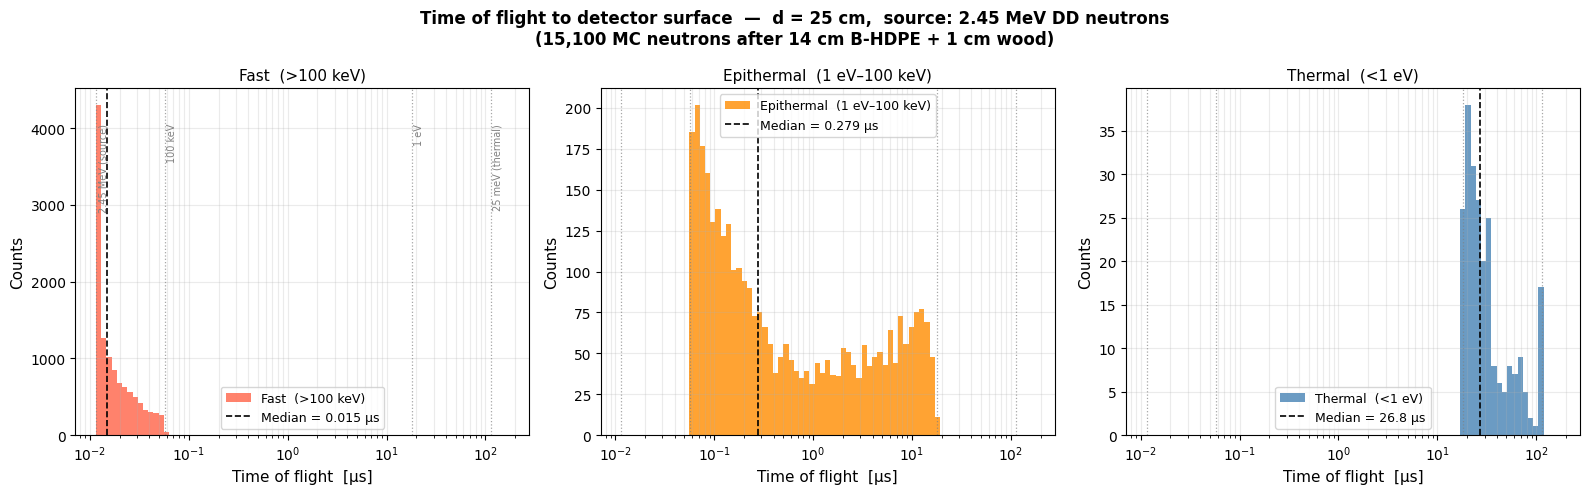

Saved → pns_tof_histograms.png


In [8]:
from lib_neutrons import tof_constant_energy

# ─── ToF at detector surface (free-flight from source, distance = DISTANCE_CM) ─
# This is a lower bound on the true ToF (ignores time spent bouncing in shield),
# but the shield is only 15 cm vs 100 cm total, so the correction is small for
# fast neutrons and negligible for thermal ones (slow inside too, but isotropic).
tof_us = tof_constant_energy(E_surv, DISTANCE_CM) * 1e6   # convert s → μs

# ─── Energy group masks ───────────────────────────────────────────────────────
mask_thermal    = E_surv <  1.0
mask_epithermal = (E_surv >= 1.0) & (E_surv < 1e5)
mask_fast       = E_surv >= 1e5

# ─── Reference ToF values ────────────────────────────────────────────────────
tof_refs = {
    '2.45 MeV (source)': tof_constant_energy(E0_MEV * 1e6, DISTANCE_CM) * 1e6,
    '100 keV':           tof_constant_energy(1e5,           DISTANCE_CM) * 1e6,
    '1 eV':              tof_constant_energy(1.0,           DISTANCE_CM) * 1e6,
    '25 meV (thermal)':  tof_constant_energy(E_THERMAL_EV,  DISTANCE_CM) * 1e6,
}
print(f"Reference ToF values at {DISTANCE_CM:.0f} cm:")
for label, t in tof_refs.items():
    print(f"  {label:<22}: {t*1e3:.1f} ns  =  {t:.3f} μs")

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

tof_bins = np.logspace(
    np.log10(max(tof_us.min(), 1e-3)),
    np.log10(tof_us.max() * 1.5),
    80)

group_defs = [
    (mask_fast,        'Fast  (>100 keV)',       'tomato',     axes[0]),
    (mask_epithermal,  'Epithermal  (1 eV–100 keV)', 'darkorange', axes[1]),
    (mask_thermal,     'Thermal  (<1 eV)',        'steelblue',  axes[2]),
]

for mask, label, color, ax in group_defs:
    if np.any(mask):
        ax.hist(tof_us[mask], bins=tof_bins, color=color, alpha=0.8,
                edgecolor='none', label=label)
        ax.axvline(np.median(tof_us[mask]), color='black', ls='--', lw=1.2,
                   label=f'Median = {np.median(tof_us[mask]):.3g} μs')

    # shared reference lines
    for ref_label, t_ref in tof_refs.items():
        ax.axvline(t_ref, color='gray', ls=':', lw=0.9, alpha=0.7)

    ax.set_xscale('log')
    ax.set_xlabel('Time of flight  [μs]', fontsize=11)
    ax.set_ylabel('Counts', fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.25)

# Annotate reference lines on the first panel
for ref_label, t_ref in tof_refs.items():
    axes[0].text(t_ref * 1.05, axes[0].get_ylim()[1] * 0.9,
                 ref_label, rotation=90, fontsize=7, va='top', color='gray')

fig.suptitle(
    f'Time of flight to detector surface  —  '
    f'd = {DISTANCE_CM:.0f} cm,  source: {E0_MEV} MeV DD neutrons\n'
    f'({n_surv:,} MC neutrons after {PE_THICKNESS_CM:.0f} cm B-HDPE + {WOOD_THICKNESS_CM:.0f} cm wood)',
    fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('pns_tof_histograms.png', dpi=120)
plt.show()
print("Saved → pns_tof_histograms.png")


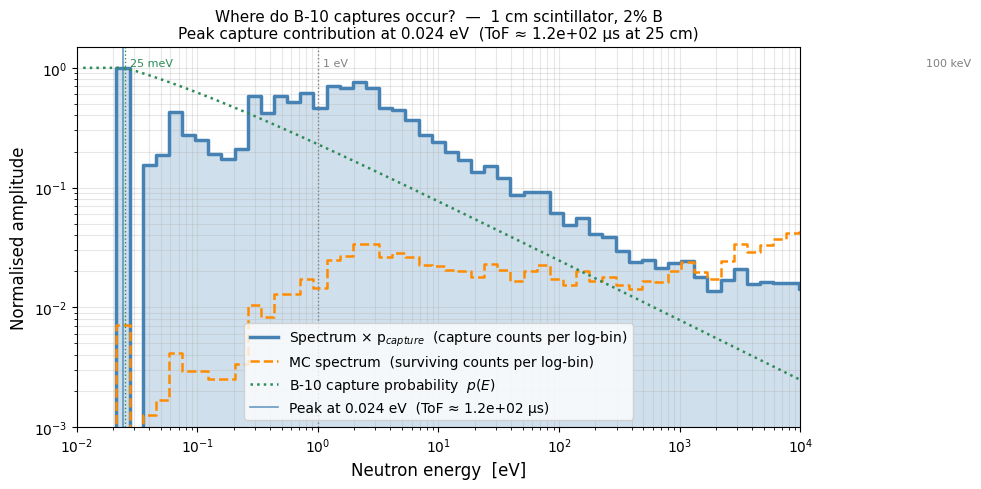

Peak capture contribution at  : 0.024 eV
Corresponding ToF at 25 cm      : 117 μs
B-10 capture prob at peak     : 61.95%


In [9]:
# ─── Spectrum × capture probability → where do captures actually happen? ──────
# Use the same log-energy bins as before
bins_cap  = np.logspace(np.log10(E_MIN_EV), np.log10(E_MAX_EV), 80)
bc        = np.sqrt(bins_cap[:-1] * bins_cap[1:])   # geometric bin centres

# MC spectrum: raw counts per log-bin (proportional to lethargy flux E * dΦ/dE)
# This is much better for visualising log-binned data than density=True, 
# which artificially over-inflates the thermal pile-up peak due to tiny ΔE!
counts, _ = np.histogram(E_surv, bins=bins_cap)

# B-10 capture probability at each bin centre
sigma_b10_bc = SIGMA_B10_THERMAL_BARNS * np.sqrt(E_THERMAL_EV / np.maximum(bc, E_THERMAL_EV))
Sigma_b10_bc = n_B10_scint * sigma_b10_bc * 1e-24
p_cap_bc     = 1.0 - np.exp(-Sigma_b10_bc * SCINT_THICKNESS_CM)

# Product: capture rate density per energy log-bin
capture_rate_density = counts * p_cap_bc

# Normalise each curve to its own max for overlay
spec_norm  = counts / counts.max()
pcap_norm  = p_cap_bc / p_cap_bc.max()
prod_norm  = capture_rate_density / capture_rate_density.max()

# Peak energy
peak_E = bc[np.argmax(capture_rate_density)]
peak_tof_us = tof_constant_energy(peak_E, DISTANCE_CM) * 1e6

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(bc, prod_norm,  alpha=0.25, color='steelblue', step='mid')
ax.step(bc, prod_norm,  where='mid', color='steelblue', lw=2.5,
        label='Spectrum × p$_{capture}$  (capture counts per log-bin)')
ax.step(bc, spec_norm,  where='mid', color='darkorange',  lw=1.8, ls='--',
        label='MC spectrum  (surviving counts per log-bin)')
ax.plot(bc, pcap_norm,  color='seagreen',   lw=1.8, ls=':',
        label='B-10 capture probability  $p(E)$')

ax.axvline(peak_E, color='steelblue', ls='-', lw=1.2, alpha=0.8,
           label=f'Peak at {peak_E:.2g} eV  (ToF ≈ {peak_tof_us:.2g} μs)')

# Mark energy group boundaries
for E_bound, label_b in [(1.0, '1 eV'), (1e5, '100 keV')]:
    ax.axvline(E_bound, color='gray', ls=':', lw=1.0)
    ax.text(E_bound * 1.1, 0.97, label_b, fontsize=8, va='top', color='gray',
            transform=ax.get_xaxis_transform())

ax.axvline(E_THERMAL_EV, color='seagreen', ls=':', lw=1.0)
ax.text(E_THERMAL_EV * 1.1, 0.97, '25 meV', fontsize=8, va='top',
        color='seagreen', transform=ax.get_xaxis_transform())

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Neutron energy  [eV]', fontsize=12)
ax.set_ylabel('Normalised amplitude', fontsize=12)
ax.set_title(
    f'Where do B-10 captures occur?  —  '
    f'{SCINT_THICKNESS_CM:.0f} cm scintillator, {SCINT_BORON_FRAC*100:.0f}% B\n'
    f'Peak capture contribution at {peak_E:.2g} eV  '
    f'(ToF ≈ {peak_tof_us:.2g} μs at {DISTANCE_CM:.0f} cm)',
    fontsize=11)
ax.set_xlim(E_MIN_EV, 1e4) # zoomed into thermal, epithermal and fast tail
ax.set_ylim(1e-3, 1.5)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('pns_capture_peak.png', dpi=120)
plt.show()

print(f"Peak capture contribution at  : {peak_E:.3g} eV")
print(f"Corresponding ToF at {DISTANCE_CM:.0f} cm      : {peak_tof_us:.3g} μs")
print(f"B-10 capture prob at peak     : {p_cap_bc[np.argmax(capture_rate_density)]*100:.2f}%")

In [10]:
# ─── Bunch structure ─────────────────────────────────────────────────────────
BUNCH_WIDTH_US  = 10.0    # [µs]  pulse length
BUNCH_GAP_US    = 200.0   # [µs]  dead time between pulses
BUNCH_PERIOD_US = BUNCH_WIDTH_US + BUNCH_GAP_US   # 210 µs → 4.76 kHz rep rate
DUTY_CYCLE      = BUNCH_WIDTH_US / BUNCH_PERIOD_US

print(f"Bunch width   : {BUNCH_WIDTH_US:.0f} µs")
print(f"Bunch gap     : {BUNCH_GAP_US:.0f} µs")
print(f"Period        : {BUNCH_PERIOD_US:.0f} µs  →  {1e6/BUNCH_PERIOD_US:.2f} kHz")
print(f"Duty cycle    : {DUTY_CYCLE*100:.2f}%  (≈ 5%)")
print()

# ─── Time-averaged B-10 capture rate ─────────────────────────────────────────
# event_rate was computed assuming EMISSION_RATE = 1e7 n/s at 100% uptime.
avg_rate_hz = event_rate * DUTY_CYCLE

print(f"B-10 captures @ 100% uptime  : {event_rate:.4f} Hz")
print(f"Duty cycle correction        : × {DUTY_CYCLE:.4f}")
print()
print(f"╔══════════════════════════════════════════════════════════╗")
print(f"║  B-10 capture rate in scintillator  (time-averaged)     ║")
print(f"║                                                          ║")
print(f"║   {avg_rate_hz*1e3:.2f} mHz   =   {avg_rate_hz:.5f} Hz                     ║")
print(f"║                                                          ║")
print(f"║   {avg_rate_hz*3600:.2f} events/hr                               ║")
print(f"║   {avg_rate_hz*3600*24:.0f} events/day                            ║")
print(f"╚══════════════════════════════════════════════════════════╝")

Bunch width   : 10 µs
Bunch gap     : 200 µs
Period        : 210 µs  →  4761.90 kHz
Duty cycle    : 4.76%  (≈ 5%)

B-10 captures @ 100% uptime  : 15.0652 Hz
Duty cycle correction        : × 0.0476

╔══════════════════════════════════════════════════════════╗
║  B-10 capture rate in scintillator  (time-averaged)     ║
║                                                          ║
║   717.39 mHz   =   0.71739 Hz                     ║
║                                                          ║
║   2582.60 events/hr                               ║
║   61982 events/day                            ║
╚══════════════════════════════════════════════════════════╝
